# FRB Isotropy Test - Level 4

Pipeline modular para rodar o `code4_jackknife.py` por partes. Execute somente as etapas que precisam ser recalculadas.


In [1]:
# ==============================================================
# 0. Imports and run configuration
# ==============================================================

%load_ext autoreload
%autoreload 2

from code4_jackknife import *

RUN_SENSITIVITY = False   # Set True only for the full empirical robustness scan.
SAVE_TABLES = True
N_JOBS = -1
TABLE_PREFIX = "Level4"


## 1. Data

Carrega o catálogo e aplica a máscara galáctica. Reexecute esta parte quando mudar catálogo, máscara ou caminho de entrada.


In [2]:
# ==============================================================
# 1. Load and mask data
# ==============================================================

print(f"\n--- Processing data ({BIN_TYPE}, Level 4) ---")
df_data = apply_mask(load_catalog(ALL_FRB_PATH))
print(f"Masked catalog size: {len(df_data)}")



--- Processing data (Linear, Level 4) ---
Masked catalog size: 2732


## 2. Selection Functions

Constrói as funções de seleção por survey e roda a validação visual/numérica. Reexecute quando mudar `NSIDE_SF`, `SMOOTH_SIGMA`, `GAL_CUT` ou o catálogo.



--- Selection Function Validation ---

ZTF:
  Weight: 0.04%
  Peak density at: RA=231.8 deg, DEC=75.3 deg
  Active coverage: 2.6%
  Entropy: 8.98 bits

CRAFT:
  Weight: 1.21%
  Peak density at: RA=351.6 deg, DEC=-32.1 deg
  Active coverage: 34.3%
  Entropy: 13.05 bits

MeerTRAP:
  Weight: 0.29%
  Peak density at: RA=327.0 deg, DEC=-79.0 deg
  Active coverage: 17.4%
  Entropy: 11.88 bits

Pan-STARRS:
  Weight: 0.15%
  Peak density at: RA=2.8 deg, DEC=-36.4 deg
  Active coverage: 10.1%
  Entropy: 10.97 bits

VLA-realfast:
  Weight: 0.07%
  Peak density at: RA=10.5 deg, DEC=41.8 deg
  Active coverage: 1.4%
  Entropy: 8.10 bits

ATLAS:
  Weight: 0.11%
  Peak density at: RA=308.7 deg, DEC=-22.0 deg
  Active coverage: 7.0%
  Entropy: 10.51 bits

GaiaAlerts:
  Weight: 0.07%
  Peak density at: RA=308.7 deg, DEC=-22.0 deg
  Active coverage: 4.9%
  Entropy: 9.96 bits

Tianlai:
  Weight: 0.04%
  Peak density at: RA=195.5 deg, DEC=48.9 deg
  Active coverage: 2.6%
  Entropy: 8.99 bits

ALERT:
  We

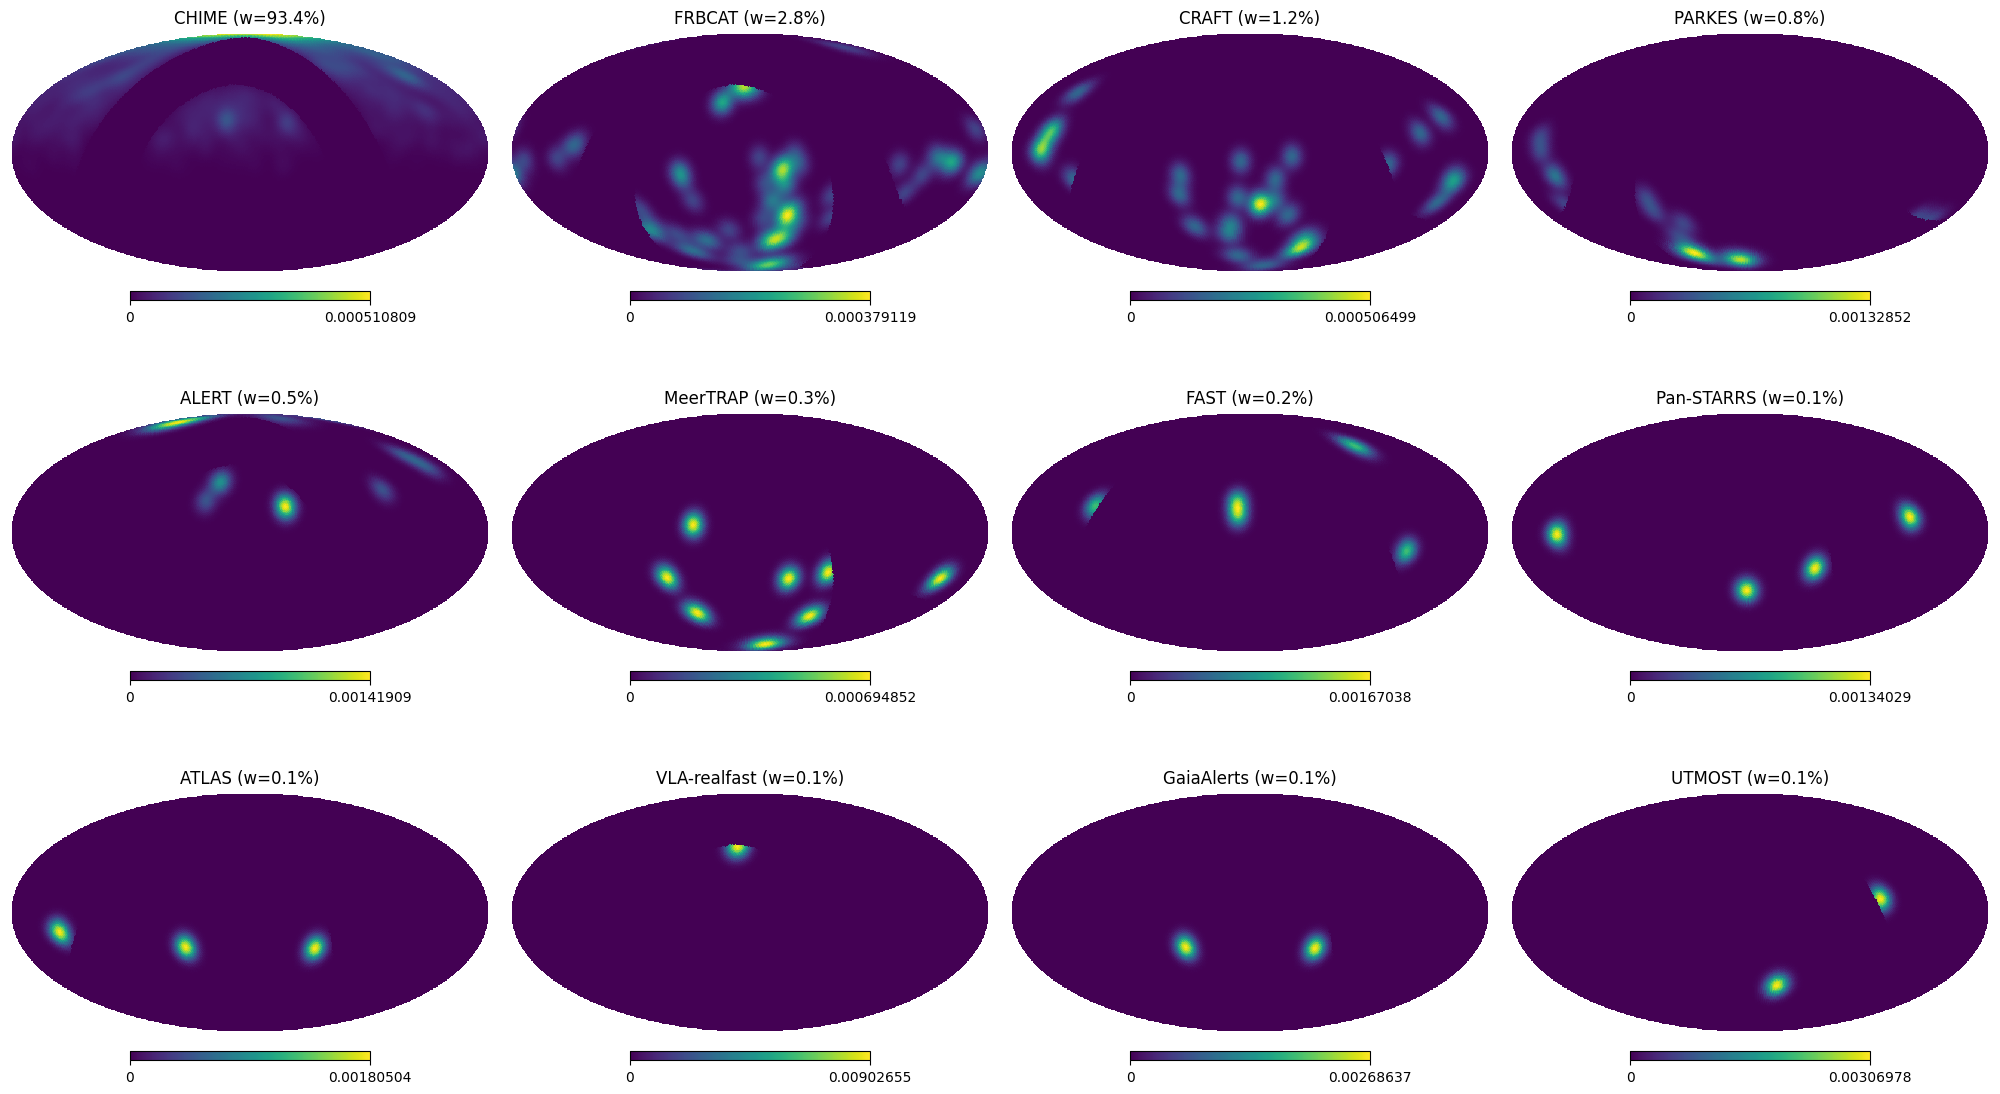

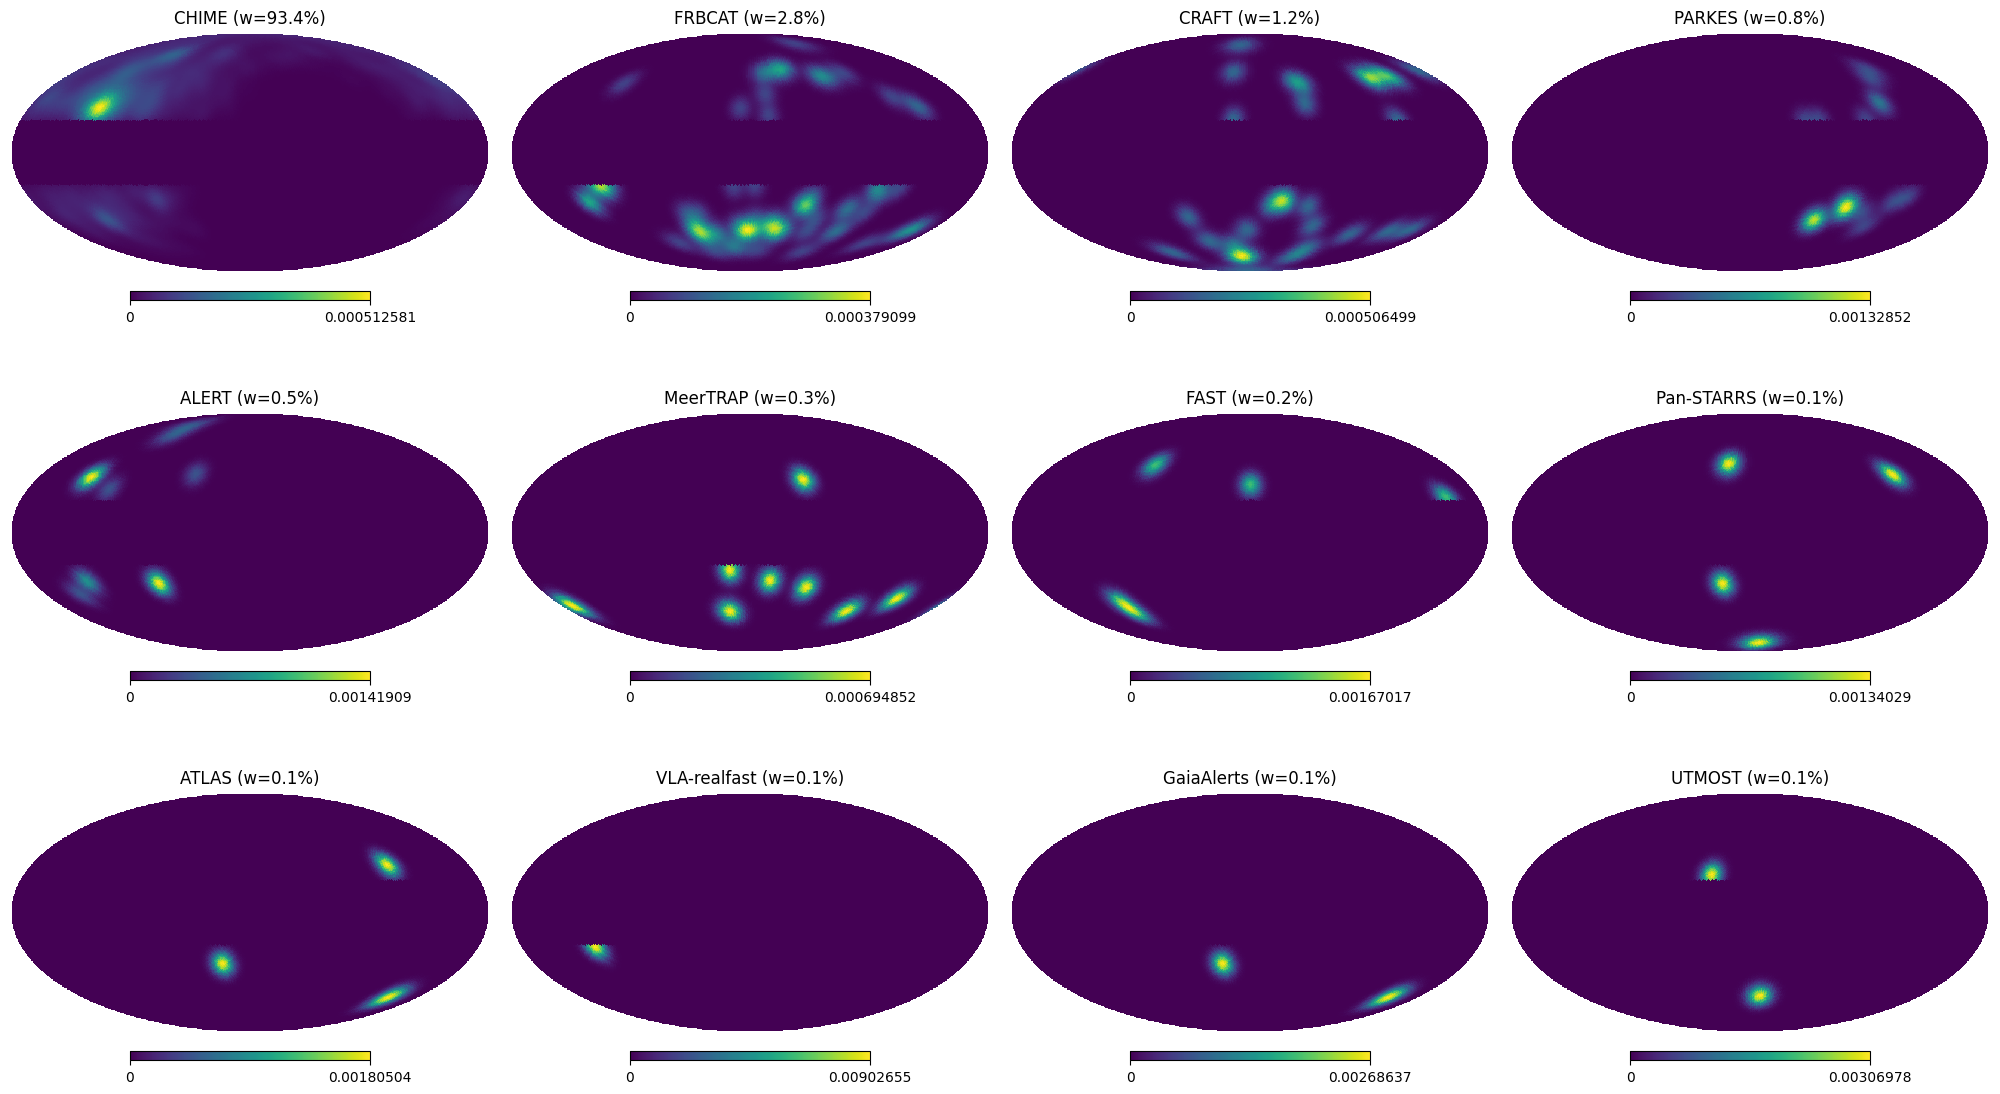

In [3]:
# ==============================================================
# 2. Build and validate survey selection functions
# ==============================================================

sf_dict, sf_cov_diag_dict, survey_weights, sf_nside = build_survey_selection_functions_improved(
    df_data,
    nside=NSIDE_SF,
    smooth_sigma=SMOOTH_SIGMA,
)

validator = SelectionFunctionValidator(sf_dict, survey_weights, sf_nside)
sf_validation = validator.check_coverage()
validator.plot_sf(
    save_prefix="SF_validation_level4",
)

## 3. Survey Diagnostics

Diagnósticos de correlação/overlap entre surveys. Pode ser pulado se você já tem esses objetos em memória e não mudou as funções de seleção ou o catálogo.


In [4]:
# ==============================================================
# 3. Intersurvey diagnostics
# ==============================================================

corr_df, overlap_df = analyze_intersurvey_correlations(df_data)



--- Spatial Correlation Matrix (Pearson) ---
                ZTF  CRAFT  MeerTRAP  Pan-STARRS  VLA-realfast  ATLAS  \
ZTF           1.000 -0.000    -0.000      -0.000        -0.000 -0.000   
CRAFT        -0.000  1.000     0.060      -0.001        -0.001 -0.001   
MeerTRAP     -0.000  0.060     1.000      -0.000        -0.000 -0.000   
Pan-STARRS   -0.000 -0.001    -0.000       1.000        -0.000  0.288   
VLA-realfast -0.000 -0.001    -0.000      -0.000         1.000 -0.000   
ATLAS        -0.000 -0.001    -0.000       0.288        -0.000  1.000   
GaiaAlerts   -0.000 -0.001    -0.000       0.353        -0.000  0.816   
Tianlai      -0.000 -0.000    -0.000      -0.000        -0.000 -0.000   
ALERT        -0.000 -0.002    -0.001      -0.001        -0.000 -0.000   
TRAPUM       -0.000 -0.000    -0.000      -0.000        -0.000 -0.000   
UTMOST       -0.000 -0.001    -0.000      -0.000        -0.000 -0.000   
FRBCAT       -0.001  0.051     0.035      -0.001        -0.001 -0.001   
VLITE

## 4. Observed Signal

Gera o catálogo aleatório observado e calcula `w(theta)` e `|<w>|` para os dados reais.


In [5]:
# ==============================================================
# 4. Observed 2pACF and absolute-sum statistic
# ==============================================================

df_rand_obs = generate_mixture_catalog_improved(
    n=len(df_data) * N_RAND_FACTOR,
    sf_dict=sf_dict,
    weights=survey_weights,
    nside=sf_nside,
    seed=2000,
)

theta, w_obs = compute_2pacf(df_data, df_rand_obs, log_spacing=USE_LOG)
abs_obs = get_absolute_sum(theta, w_obs)

print("theta bins:", theta.shape)
print("w_obs:", w_obs.shape)
print("abs_obs:", abs_obs.shape)


theta bins: (17,)
w_obs: (17,)
abs_obs: (9,)


## 5. Jackknife

Etapa pesada, mas independente dos mocks H0. Reexecute quando mudar parâmetros de jackknife ou funções que entram no cálculo de `w(theta)`.


In [6]:
# ==============================================================
# 5. Jackknife errors
# ==============================================================

jackknife = run_jackknife_errors(
    df_data,
    sf_dict,
    survey_weights,
    sf_nside,
    nside_jackknife=NSIDE_JACKKNIFE,
    min_regions=MIN_JACKKNIFE_REGIONS,
    n_jobs=N_JOBS,
)



--- Jackknife regions ---
NSIDE_JACKKNIFE = 8
Populated regions = 366
Objects per region: min=1, median=5.0, max=80


Jackknife regions:   0%|          | 0/366 [00:00<?, ?it/s]

  0%|          | 0/366 [00:00<?, ?it/s]


--- Jackknife summary ---
Leave-one-region samples = 366
Objects kept per sample: min=2652, max=2731
Median sigma[w(theta)] = 2.3309e-02
Median sigma[|<w>|] = 1.3723e-02


## 6. H0 Ensemble Mocks

Etapa pesada. Reexecute quando mudar funções de seleção, número de mocks, escala de perturbação ou estatística de `w(theta)`.


In [7]:
# ==============================================================
# 6. H0 ensemble mocks
# ==============================================================

all_w_h0, all_abs_h0 = run_ensemble_mocks(
    df_data,
    sf_dict,
    sf_cov_diag_dict,
    survey_weights,
    sf_nside,
    n_ensemble=N_ENSEMBLE,
    n_mocks_per=N_MOCKS_PER_ENSEMBLE,
    perturbation_scale=PERTURBATION_SCALE,
    n_jobs=N_JOBS,
)

print("all_w_h0:", all_w_h0.shape)
print("all_abs_h0:", all_abs_h0.shape)



--- Generating H0 ensemble mocks (20 SF variants x 100 mocks) ---


H0 ensemble mocks:   0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

all_w_h0: (2000, 17)
all_abs_h0: (2000, 9)


## 7. Statistics And Plots

Calcula os testes estatísticos e gera as figuras usando os objetos já calculados.


Max |H0 mean| = 8.2492e-04


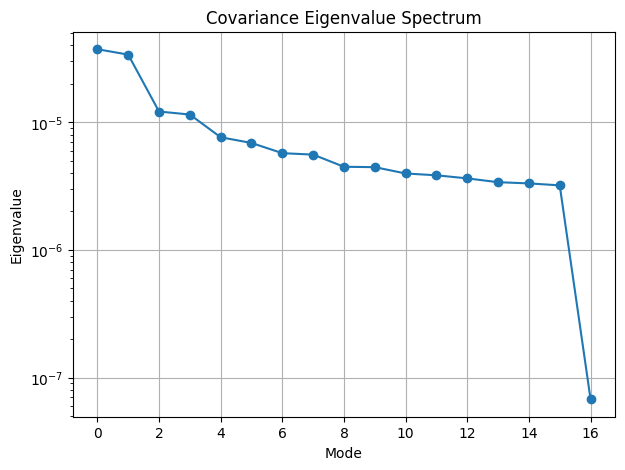

Effective number of modes = 7.35

--- Full covariance diagnostic (Level 4: jackknife errors) ---
Chi2 = 32.261
Chi2/dof = 2.016
p-value (Chi2 analytic) = 9.2445e-03
p-value (Chi2 empirical) = 2.6487e-02
Sigma-equivalent (from empirical p) = 1.94

--- Primary isotropy statistic (SVD-regularized) ---
Eigenvalue cut = 1.0e-02
SVD modes kept = 16/17
Chi2 SVD = 29.812
Chi2 SVD/dof = 1.863
p-value SVD (Chi2 analytic) = 1.9003e-02
p-value SVD (empirical) = 3.7481e-02
Sigma-equivalent SVD (from empirical p) = 1.78

--- Covariance diagnostics ---
Mocks = 2000
Bins = 17
Covariance rank = 17/17
Covariance condition number = 5.4983e+02
SVD retained condition number = 1.1639e+01
Effective modes = 7.35
RMS normalized deviation = 1.395
Hartlap factor = 0.991

--- Non-parametric profile tests ---
w(theta) KS: D=0.529, p=1.5561e-02, p_emp=5.3373e-01
w(theta) AD: A2=4.435, p=5.5653e-03, p_emp=3.7781e-01
|<w>| KS: D=0.667, p=3.3566e-02, p_emp=1.5592e-01
|<w>| AD: A2=2.002, p=4.8659e-02, p_emp=1.6692e-01


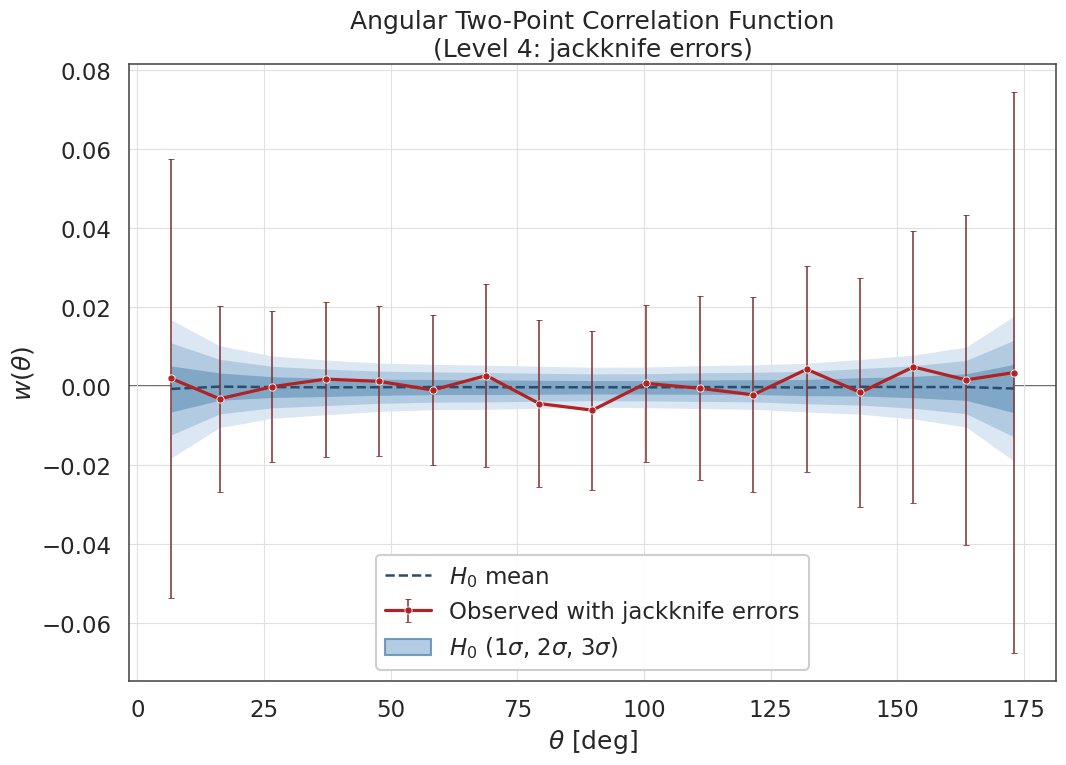

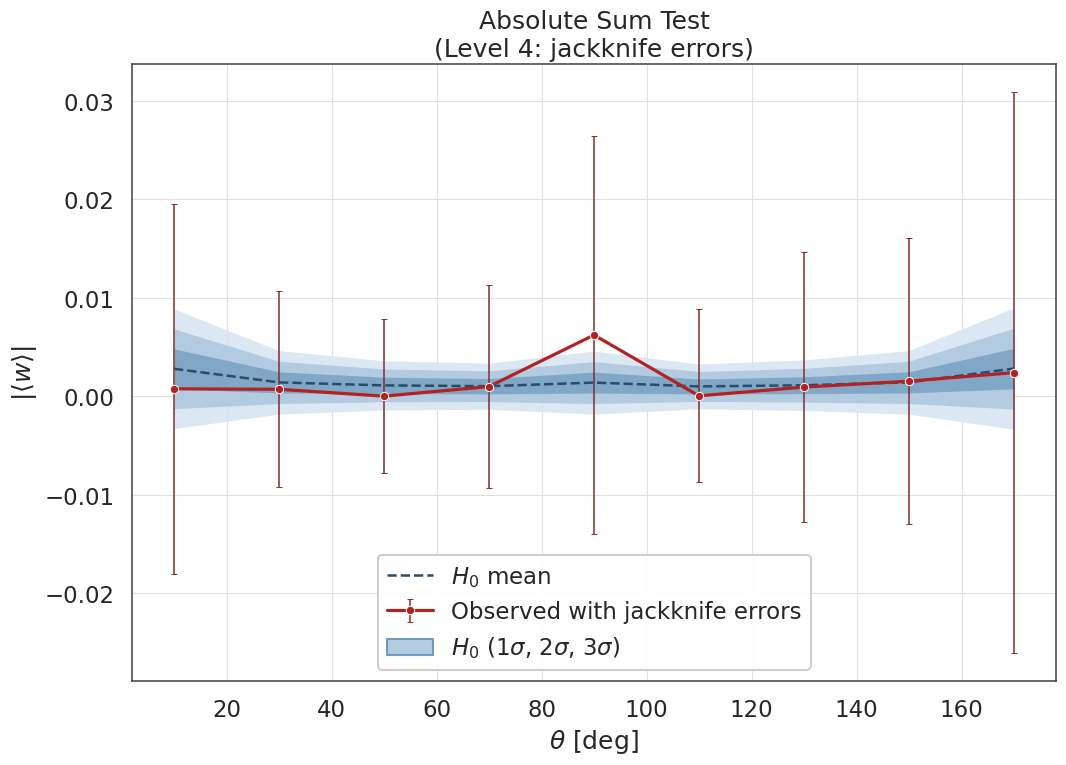

In [8]:
# ==============================================================
# 7. Statistical tests and Level 4 plots
# ==============================================================

stats = compute_statistics(
    w_obs,
    abs_obs,
    all_w_h0,
    all_abs_h0,
    label="Level 4: jackknife errors",
)

plot_results_with_jackknife(
    theta,
    w_obs,
    abs_obs,
    all_w_h0,
    all_abs_h0,
    jackknife,
)


## 8. Optional Sensitivity Scan

Desligado por padrão porque é caro. Mude `RUN_SENSITIVITY = True` na configuração inicial quando quiser rodar.


In [9]:
# # ==============================================================
# # 8. Optional empirical sensitivity analysis
# # ==============================================================

# sensitivity_results = None
# if RUN_SENSITIVITY:
#     sensitivity_results = run_empirical_sensitivity_analysis(
#         df_data,
#         n_jobs=N_JOBS,
#     )
# else:
#     print("Sensitivity scan skipped. Set RUN_SENSITIVITY = True to run it.")


## 9. Assemble Results And Save Tables

Reconstrói o dicionário `results` no mesmo formato de `main_level4`, para manter compatibilidade com análises antigas.


In [10]:
# ==============================================================
# 9. Assemble result dictionary and save optimized outputs
# ==============================================================

results = {
    "df_data": df_data,
    "theta": theta,
    "w_obs": w_obs,
    "abs_obs": abs_obs,
    "sf_dict": sf_dict,
    "sf_cov_diag_dict": sf_cov_diag_dict,
    "survey_weights": survey_weights,
    "sf_validation": sf_validation,
    "intersurvey_corr": corr_df,
    "intersurvey_overlap": overlap_df,
    "jackknife": jackknife,
    "all_w_h0": all_w_h0,
    "all_abs_h0": all_abs_h0,
    "stats": stats,
}

# ==============================================================
# Save outputs
# ==============================================================

if SAVE_TABLES:

    import pandas as pd

    # ----------------------------------------------------------
    # 1. Main scientific summary CSV
    # ----------------------------------------------------------

    stats_rows = [

        # ======================================================
        # FULL covariance diagnostic
        # ======================================================

        ["chi2", "chi2",
         stats.chi2,
         "Full covariance chi-square"],

        ["chi2", "chi2_red",
         stats.chi2_red,
         "Reduced chi-square"],

        ["chi2", "p_chi2_analytic",
         stats.p_chi2,
         "Analytic chi-square p-value"],

        ["chi2", "p_chi2_empirical",
         stats.p_empirical,
         "Empirical chi-square p-value"],

        ["chi2", "sigma_equiv_empirical",
         stats.sigma_equiv,
         "Gaussian sigma equivalent"],

        # ======================================================
        # SVD isotropy statistic
        # ======================================================

        ["svd", "chi2_svd",
         stats.chi2_svd,
         "SVD-regularized chi-square"],

        ["svd", "chi2_svd_red",
         stats.chi2_svd_red,
         "Reduced SVD chi-square"],

        ["svd", "p_chi2_svd_analytic",
         stats.p_chi2_svd,
         "Analytic SVD p-value"],

        ["svd", "p_chi2_svd_empirical",
         stats.p_svd_empirical,
         "Empirical SVD p-value"],

        ["svd", "sigma_svd_equiv",
         stats.sigma_svd_equiv,
         "Gaussian sigma equivalent (SVD)"],

        ["svd", "svd_modes_kept",
         stats.svd_modes_kept,
         "Retained SVD modes"],

        # ======================================================
        # Covariance diagnostics
        # ======================================================

        ["covariance", "effective_modes",
         stats.n_eff,
         "Effective covariance dimensionality"],

        ["covariance", "covariance_rank",
         stats.covariance_rank,
         "Covariance rank"],

        ["covariance", "covariance_condition",
         stats.covariance_condition,
         "Covariance condition number"],

        ["covariance", "hartlap_factor",
         stats.hartlap_factor,
         "Hartlap correction factor"],

        ["covariance", "global_tension",
         stats.global_tension,
         "RMS normalized deviation"],

        # ======================================================
        # Absolute anisotropy
        # ======================================================

        ["anisotropy", "abs_observed_stat",
         stats.abs_observed_stat,
         "Observed RMS anisotropy amplitude"],

        ["anisotropy", "abs_empirical_p",
         stats.abs_empirical_p,
         "Empirical anisotropy p-value"],

        # ======================================================
        # Non-parametric tests
        # ======================================================

        ["nonparametric", "ks_w_stat",
         stats.ks_w_stat,
         "KS statistic for w(theta)"],

        ["nonparametric", "ks_w_pvalue",
         stats.ks_w_pvalue,
         "KS p-value for w(theta)"],

        ["nonparametric", "ks_w_empirical_p",
         stats.ks_w_empirical_p,
         "Empirical KS p-value for w(theta)"],

        ["nonparametric", "ad_w_stat",
         stats.ad_w_stat,
         "AD statistic for w(theta)"],

        ["nonparametric", "ad_w_pvalue",
         stats.ad_w_pvalue,
         "AD p-value for w(theta)"],

        ["nonparametric", "ad_w_empirical_p",
         stats.ad_w_empirical_p,
         "Empirical AD p-value for w(theta)"],

        ["nonparametric", "ks_abs_stat",
         stats.ks_abs_stat,
         "KS statistic for |<w>|"],

        ["nonparametric", "ks_abs_pvalue",
         stats.ks_abs_pvalue,
         "KS p-value for |<w>|"],

        ["nonparametric", "ks_abs_empirical_p",
         stats.ks_abs_empirical_p,
         "Empirical KS p-value for |<w>|"],

        ["nonparametric", "ad_abs_stat",
         stats.ad_abs_stat,
         "AD statistic for |<w>|"],

        ["nonparametric", "ad_abs_pvalue",
         stats.ad_abs_pvalue,
         "AD p-value for |<w>|"],

        ["nonparametric", "ad_abs_empirical_p",
         stats.ad_abs_empirical_p,
         "Empirical AD p-value for |<w>|"],
    ]

    summary_df = pd.DataFrame(
        stats_rows,
        columns=[
            "category",
            "statistic",
            "value",
            "description",
        ],
    )

    summary_df.to_csv(
        "Level4_summary.csv",
        index=False,
    )

    # ----------------------------------------------------------
    # 2. Consolidated diagnostics workbook
    # ----------------------------------------------------------

    chi2_bin_diagnostics, svd_mode_contributions = (
        compute_chi2_diagnostic_tables(
            theta,
            w_obs,
            all_w_h0,
            eigenvalue_cut=SVD_EIGENVALUE_CUT,
        )
    )

    with pd.ExcelWriter(
        "Level4_diagnostics.xlsx",
        engine="openpyxl",
    ) as writer:

        # ------------------------------------------------------
        # Jackknife diagnostics
        # ------------------------------------------------------

        pd.DataFrame(
            {
                "theta_deg": theta,
                "w_obs": w_obs,
                "w_jackknife_mean": jackknife.w_mean,
                "w_jackknife_err": jackknife.w_err,
            }
        ).to_excel(
            writer,
            sheet_name="jackknife_w",
            index=False,
        )

        pd.DataFrame(
            {
                "theta_center_deg": COARSE_CENTERS,
                "abs_obs": abs_obs,
                "abs_jackknife_mean": jackknife.abs_mean,
                "abs_jackknife_err": jackknife.abs_err,
            }
        ).to_excel(
            writer,
            sheet_name="jackknife_abs",
            index=False,
        )

        # ------------------------------------------------------
        # Covariance diagnostics
        # ------------------------------------------------------

        if "LAST_COVARIANCE_MATRIX" in globals():

            pd.DataFrame(
                LAST_COVARIANCE_MATRIX
            ).to_excel(
                writer,
                sheet_name="covariance_matrix",
                index=False,
            )

        if "LAST_EIGENVALUES" in globals():

            pd.DataFrame(
                {
                    "eigenvalue": LAST_EIGENVALUES
                }
            ).to_excel(
                writer,
                sheet_name="eigenvalues",
                index=False,
            )

        # ------------------------------------------------------
        # Chi-square diagnostics
        # ------------------------------------------------------

        chi2_bin_diagnostics.to_excel(
            writer,
            sheet_name="chi2_bins",
            index=False,
        )

        svd_mode_contributions.to_excel(
            writer,
            sheet_name="svd_modes",
            index=False,
        )

        # ------------------------------------------------------
        # Survey diagnostics
        # ------------------------------------------------------

        sf_validation.to_excel(
            writer,
            sheet_name="sf_validation",
            index=False,
        )

        corr_df.to_excel(
            writer,
            sheet_name="intersurvey_corr",
        )

        overlap_df.to_excel(
            writer,
            sheet_name="intersurvey_overlap",
        )

    # ----------------------------------------------------------
    # 3. Markdown scientific report
    # ----------------------------------------------------------

    save_level4_report(
        results,
        paths={
            "summary": "Level4_summary.csv",
            "diagnostics": "Level4_diagnostics.xlsx",
        },
        output_path="Level4_report.md",
    )

    print("\n--- Saved optimized Level 4 outputs ---")
    print("Level4_summary.csv")
    print("Level4_diagnostics.xlsx")
    print("Level4_report.md")

results.keys()


--- Saved optimized Level 4 outputs ---
Level4_summary.csv
Level4_diagnostics.xlsx
Level4_report.md


dict_keys(['df_data', 'theta', 'w_obs', 'abs_obs', 'sf_dict', 'sf_cov_diag_dict', 'survey_weights', 'sf_validation', 'intersurvey_corr', 'intersurvey_overlap', 'jackknife', 'all_w_h0', 'all_abs_h0', 'stats'])

In [11]:
# # ==============================================================
# # 9. Assemble result dictionary and save tables
# # ==============================================================

# results = {
#     "df_data": df_data,
#     "theta": theta,
#     "w_obs": w_obs,
#     "abs_obs": abs_obs,
#     "sf_dict": sf_dict,
#     "sf_cov_diag_dict": sf_cov_diag_dict,
#     "survey_weights": survey_weights,
#     "sf_validation": sf_validation,
#     "intersurvey_corr": corr_df,
#     "intersurvey_overlap": overlap_df,
#     "jackknife": jackknife,
#     "all_w_h0": all_w_h0,
#     "all_abs_h0": all_abs_h0,
#     "stats": stats,
#     "sensitivity": sensitivity_results,
# }

# if SAVE_TABLES:
#     results["saved_tables"] = save_level4_tables(results, prefix=TABLE_PREFIX)

# results.keys()


## 10. Useful Outputs

Resumo rápido para conferência depois das execuções principais.


In [12]:
# # ==============================================================
# # 10. Useful outputs
# # ==============================================================

# print(stats)
# print("Median jackknife sigma w(theta):", np.median(jackknife.w_err))
# print("Median jackknife sigma |<w>|:", np.median(jackknife.abs_err))

# if "saved_tables" in results:
#     print("Saved tables:", results["saved_tables"])

# # Tables/objects available:
# # results["sf_validation"]
# # results["intersurvey_corr"]
# # results["intersurvey_overlap"]
# # results["jackknife"].w_cov
# # results["jackknife"].abs_cov


## Optional Survey Maps

Execute apenas quando quiser gerar o mapa diagnóstico dos surveys mais importantes.


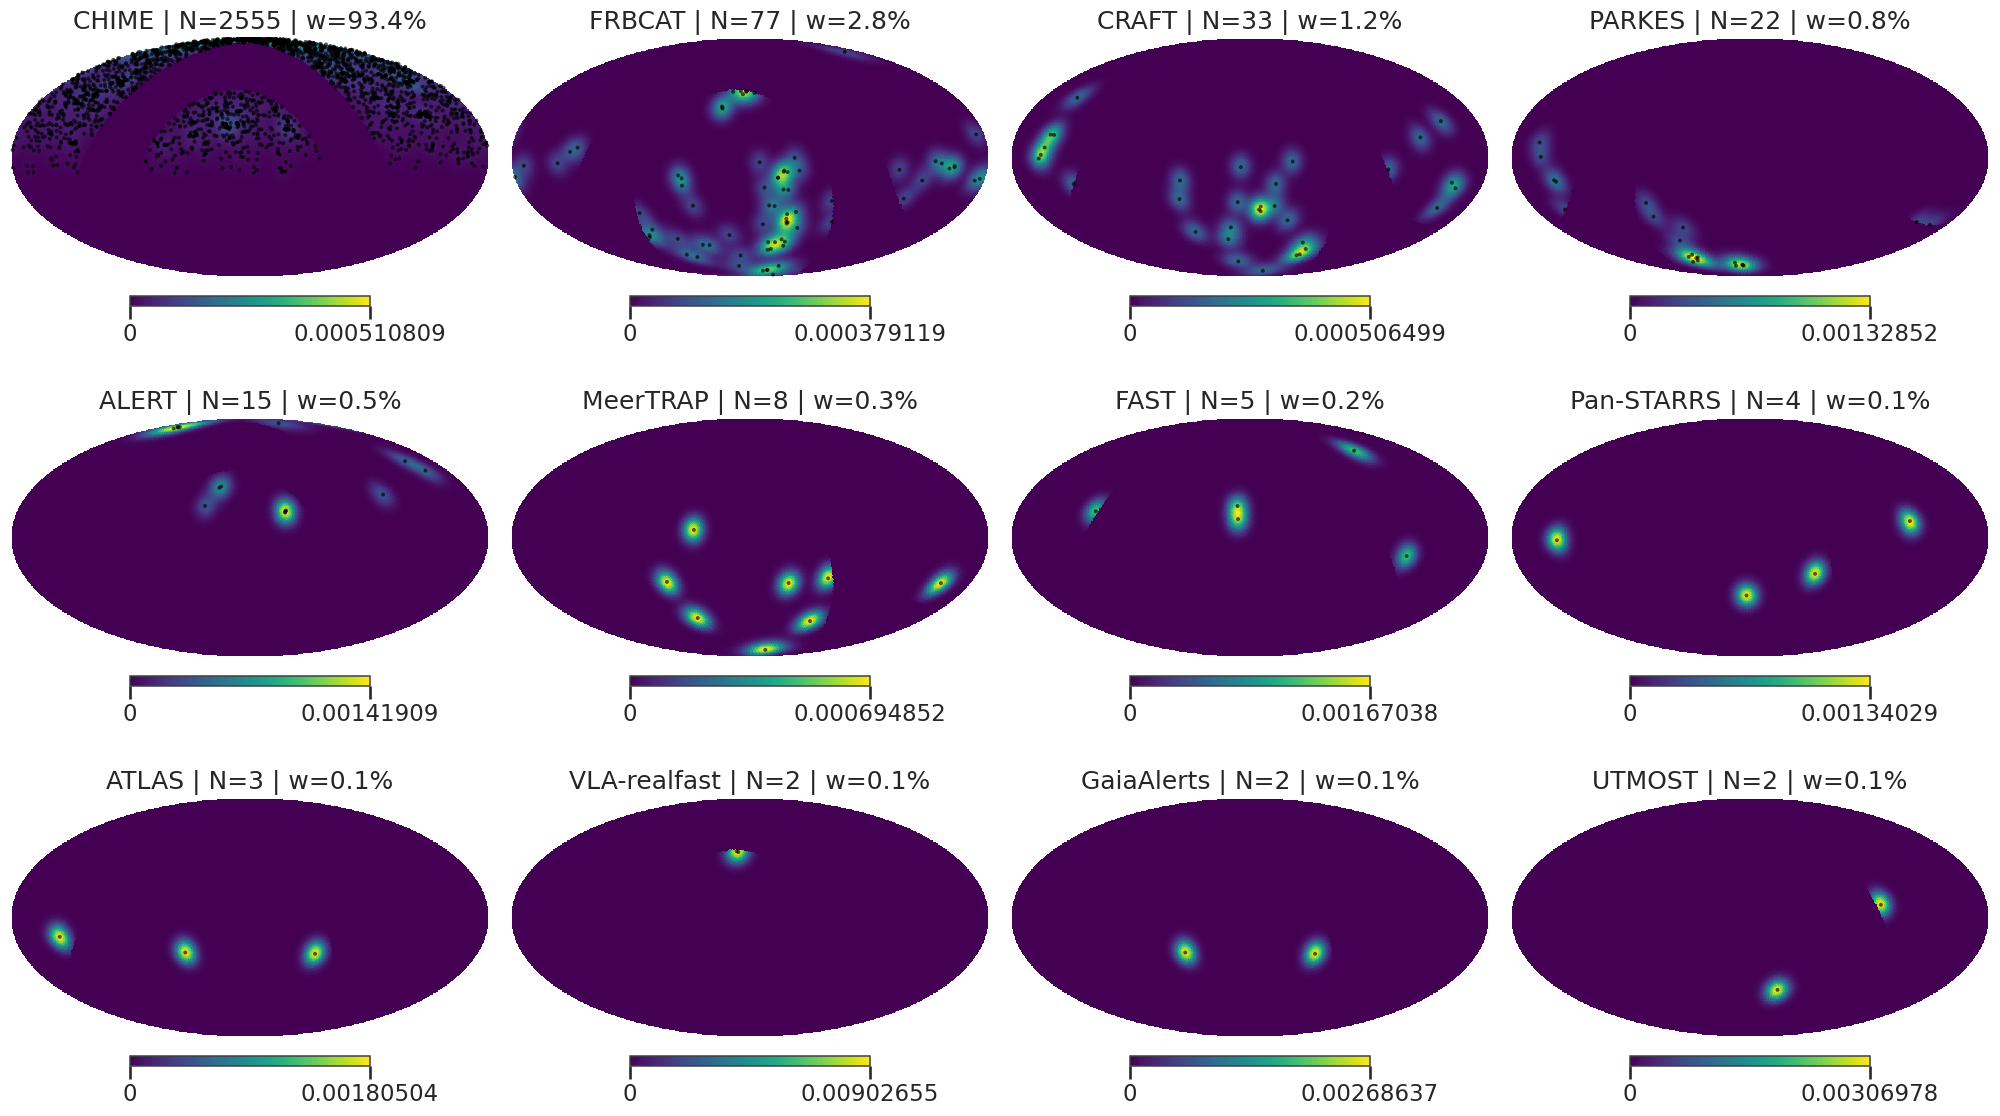

Saved survey maps: Level4_top12_survey_maps_equatorial.png


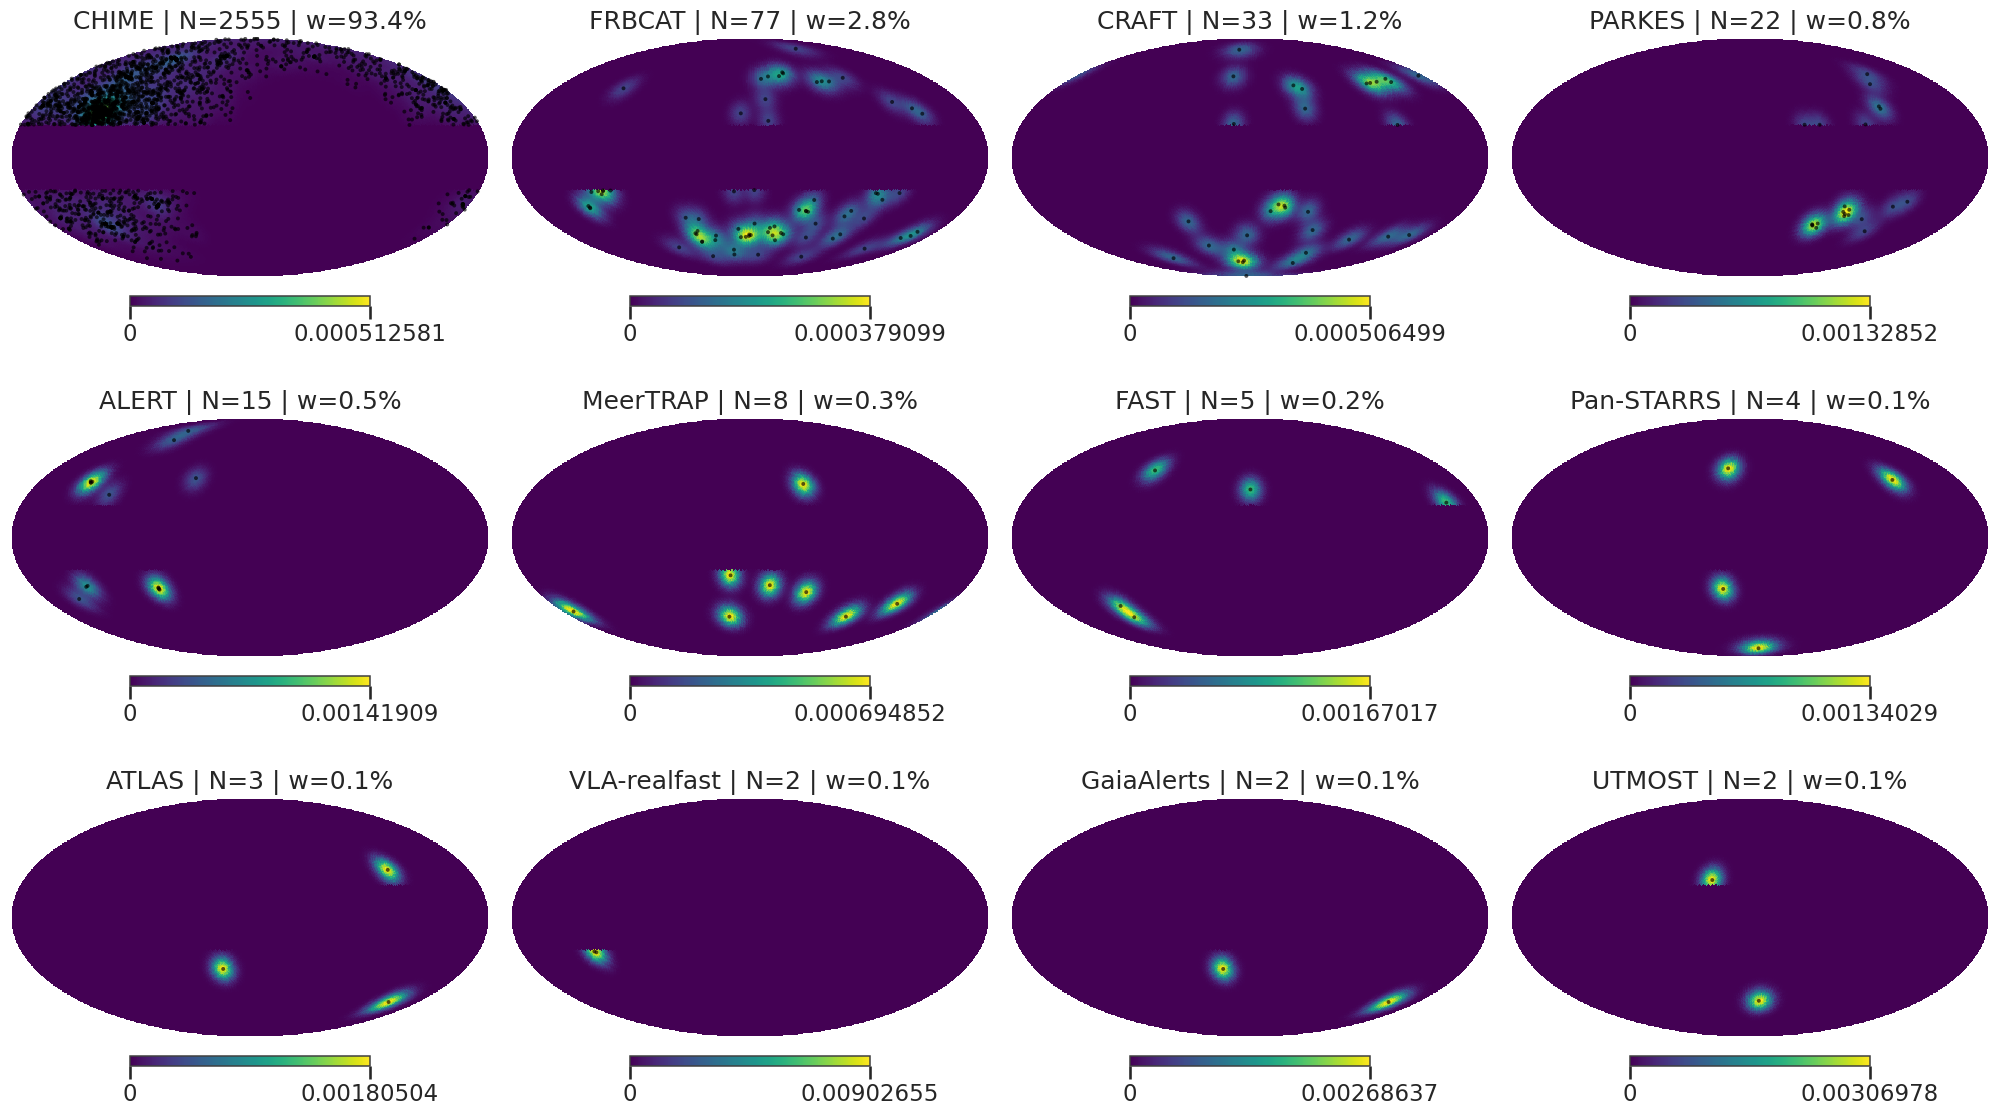

Saved survey maps: Level4_top12_survey_maps_galactic.png


,survey,n_objects,weight,active_coverage_pct,entropy_bits,nside,coordinate_system
0,CHIME,2555,0.934186,42.844645,13.657882,64,equatorial
1,FRBCAT,77,0.028154,39.599609,13.338460,64,equatorial
2,CRAFT,33,0.012066,34.250895,13.054569,64,equatorial
3,PARKES,22,0.008044,13.120524,11.619174,64,equatorial
4,ALERT,15,0.005484,13.720703,11.505026,64,equatorial
5,MeerTRAP,8,0.002925,17.360433,11.880547,64,equatorial
6,FAST,5,0.001828,9.049479,10.871968,64,equatorial
7,Pan-STARRS,4,0.001463,10.056559,10.973066,64,equatorial
8,ATLAS,3,0.001097,7.023112,10.509451,64,equatorial
9,VLA-realfast,2,0.000731,1.383464,8.098118,64,equatorial


In [13]:
# ==============================================================
# Optional: top survey maps
# ==============================================================

survey_map_summary = plot_top_survey_maps(
    df_data,
    sf_dict,
    survey_weights,
    sf_nside,
    max_surveys=12,
    output_prefix="Level4_top12_survey_maps",
)

survey_map_summary
